In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import Rbf
import pickle

In [2]:
data_file_dir = r"D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV"

In [3]:
for file in os.listdir(data_file_dir):
    print(os.path.join(data_file_dir, file))    

D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\1_one_volt.csv
D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\2_one_point_onefive_volt.csv
D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\3_two_volt.csv
D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\4_two_point_five_volt.csv
D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\5_three_volt.csv
D:\lord_of_darkness\IITM\5th_year\DDP_Final\1_Data_Collection\Data_CSV\6_four_point_five_volt.csv


In [4]:
data_list = []
for i in range(len(os.listdir(data_file_dir))):
    data_list.append(pd.read_csv(os.path.join(data_file_dir, os.listdir(data_file_dir)[i])))

In [5]:
data_list[-1].head()

,Time,Inputs | Throttle Command,Inputs | Mapped Throttle,Inputs | Throttle Pot,Motor | Motor RPM,Vehicle | Vehicle Speed,Vehicle | Vehicle Acceleration,Vehicle | Time Between Speeds
0,00:53.4,0,0,0.28,0,0.0,0.0,19.07
1,00:53.5,0,0,0.28,0,0.0,0.0,19.07
2,00:53.5,0,0,0.28,0,0.0,0.0,19.07
3,00:53.7,0,0,0.28,0,0.0,0.0,19.07
4,00:53.7,0,0,0.28,0,0.0,0.0,19.07


In [6]:
heads = list(data_list[0].columns)

In [7]:
def remove_duplicates(index, times, throttle_cmds, throttle_pots, motor_rpms, velocities, accelerations):
    
    times_in_seconds = []
    prev_min = None
    for ts in times:
        min, ss = ts.split(':')
        sec, milli = ss.split('.')
        if prev_min is None:
            prev_min = int(min)
        elif prev_min == 59 and int(min) < prev_min:
            min = int(min) + 60
        else:
            prev_min = int(min)
        times_in_seconds.append(int(min) * 60 + int(sec) + int(milli) / 10)
    times = [round(time - times_in_seconds[0], 1) for time in times_in_seconds] 
    
    unique_dict = dict()
    for key, *values in zip(times, throttle_cmds, throttle_pots, motor_rpms, velocities, accelerations):
        if key not in unique_dict:
            unique_dict[key] = values
    altered_data = []
    altered_data.append(list(unique_dict.keys()))
    value_list = list(zip(*unique_dict.values()))
    altered_data.extend(list(lst) for lst in value_list)
    return altered_data

In [8]:
altered_data_list = []
for i, data in enumerate(data_list):
    altered_data_list.append(remove_duplicates(i, list(data[heads[0]]), list(data[heads[1]]), list(data[heads[3]]), list(data[heads[5]]), list(data[heads[6]]), list(data[heads[7]])))

In [41]:
store_brakepoints = []
for data in altered_data_list:
    start_test, start_coasting, end_coasting, flag = 0, 0, len(data[1]), 0
    counter = 0
    for i, tcmd in enumerate(data[1]):
        if flag == 0 and tcmd != 0:
            start_test, flag = i - 1, 1
        elif flag == 1 and tcmd == 0:
            start_coasting, flag = i - 1, 2
        elif flag == 2 and data[3][i] == 0:
            flag = 3
            counter += 1
        elif counter <= 5 and flag == 3:
            counter += 1
        elif counter > 5:
            end_coasting = i
            break
            
    store_brakepoints.append((start_test, start_coasting, end_coasting))

In [42]:
print(store_brakepoints)

[(50, 283, 326), (13, 246, 299), (42, 282, 329), (46, 279, 338), (74, 286, 357), (77, 284, 380)]


In [43]:
def plot(data, brakepoints, title):
    tt, ct = data[0][brakepoints[0] : brakepoints[1] + 1], data[0][brakepoints[1] - 1 : brakepoints[2]]
    test_times, coast_times = [time - tt[0] for time in tt], [time - ct[0] for time in ct]
    plt.figure(figsize = (10, 20))    # (Width, height)
    
    ylabels = ['Throttle_cmd', 'Throttle_pot', 'Motor_rpm', 'Velocity (m/s)', 'Acceleration (m/s^2)']
    
    for i in range(len(data) - 1):
        plt.subplot(5, 2, 2 * i + 1)
        plt.plot(test_times, data[i + 1][brakepoints[0] : brakepoints[1] + 1])
        plt.ylabel(ylabels[i])
        plt.xlabel('Time (s)')
        plt.title(f'{title}_controlling')
        
        plt.subplot(5, 2, 2 * i + 2)
        plt.plot(coast_times, data[i + 1][brakepoints[1] - 1 : brakepoints[2]])
        plt.ylabel(ylabels[i])
        plt.xlabel('Time (s)')
        plt.title(f'{title}_coasting')
    plt.tight_layout()
    plt.show()    

In [44]:
titles = ['1_volt', '1.15_volt', '2_volt', '2.5_volt', '3_volt', '4.5_volt']

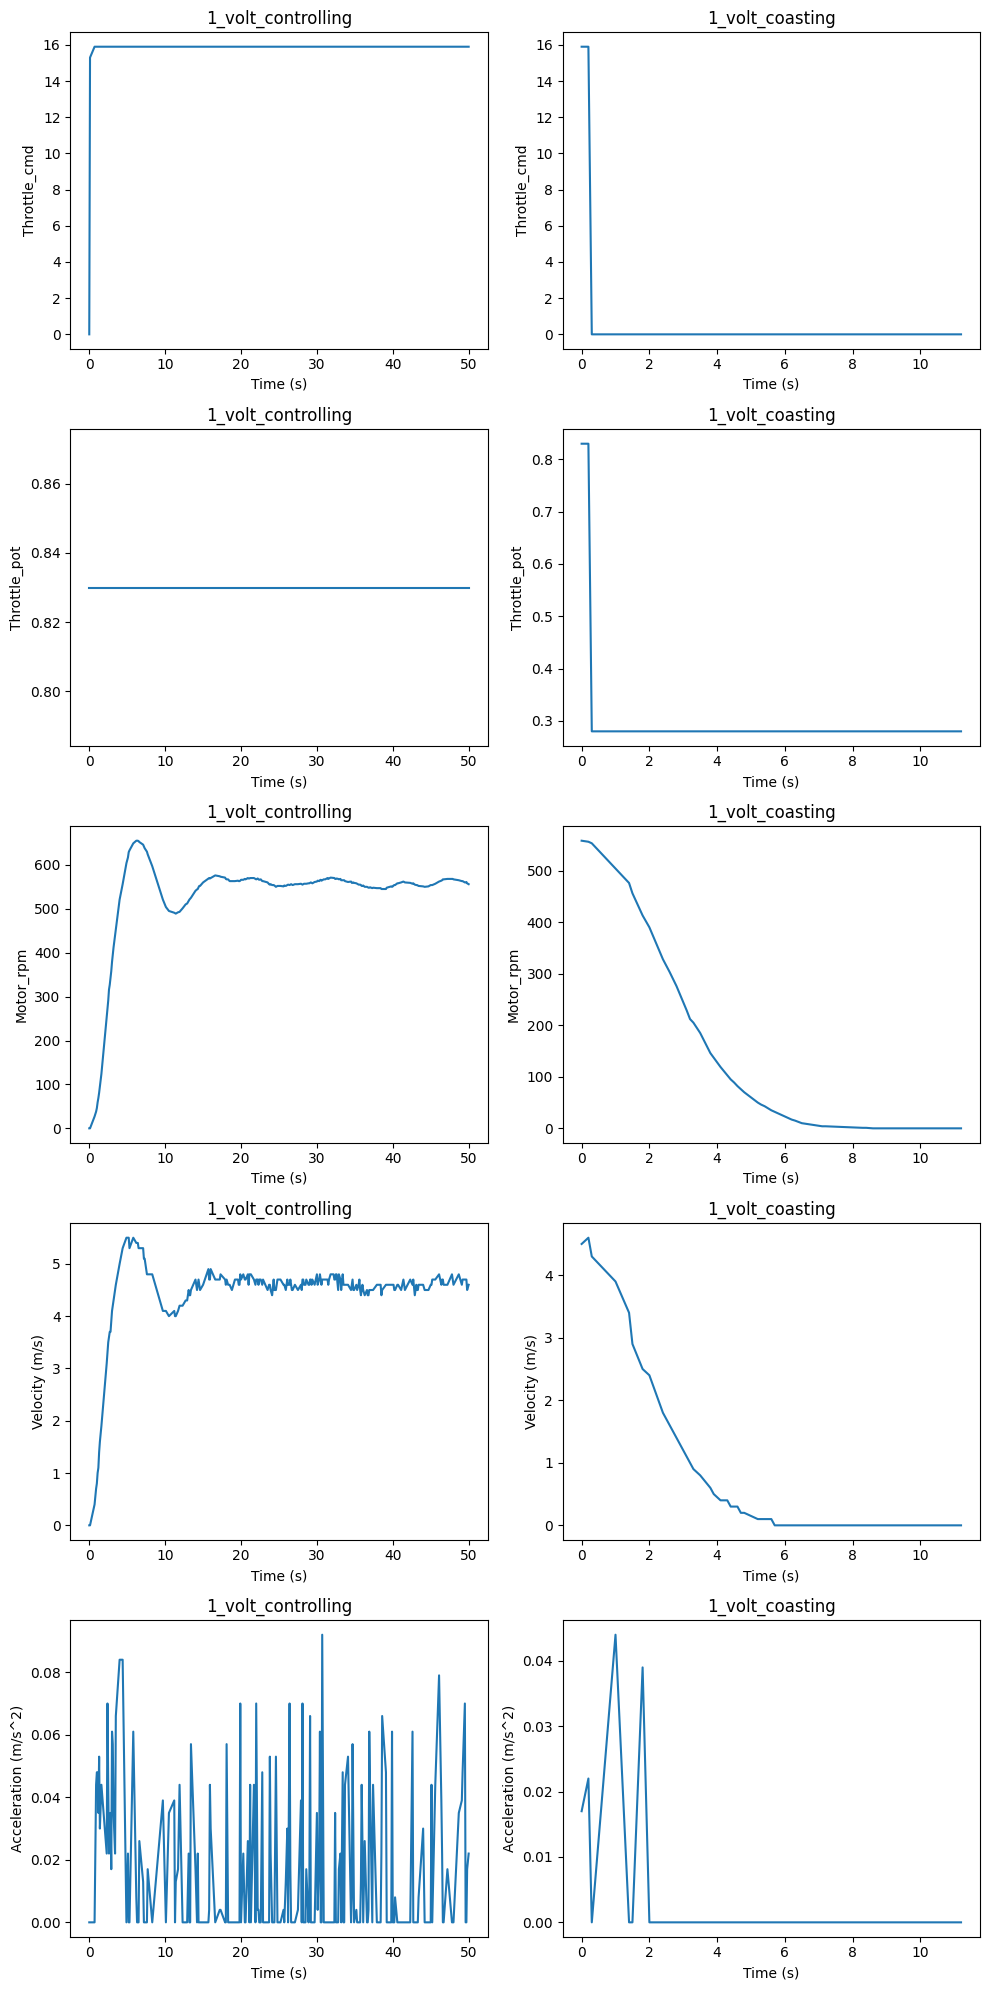

In [45]:
plot(altered_data_list[0], store_brakepoints[0], titles[0])

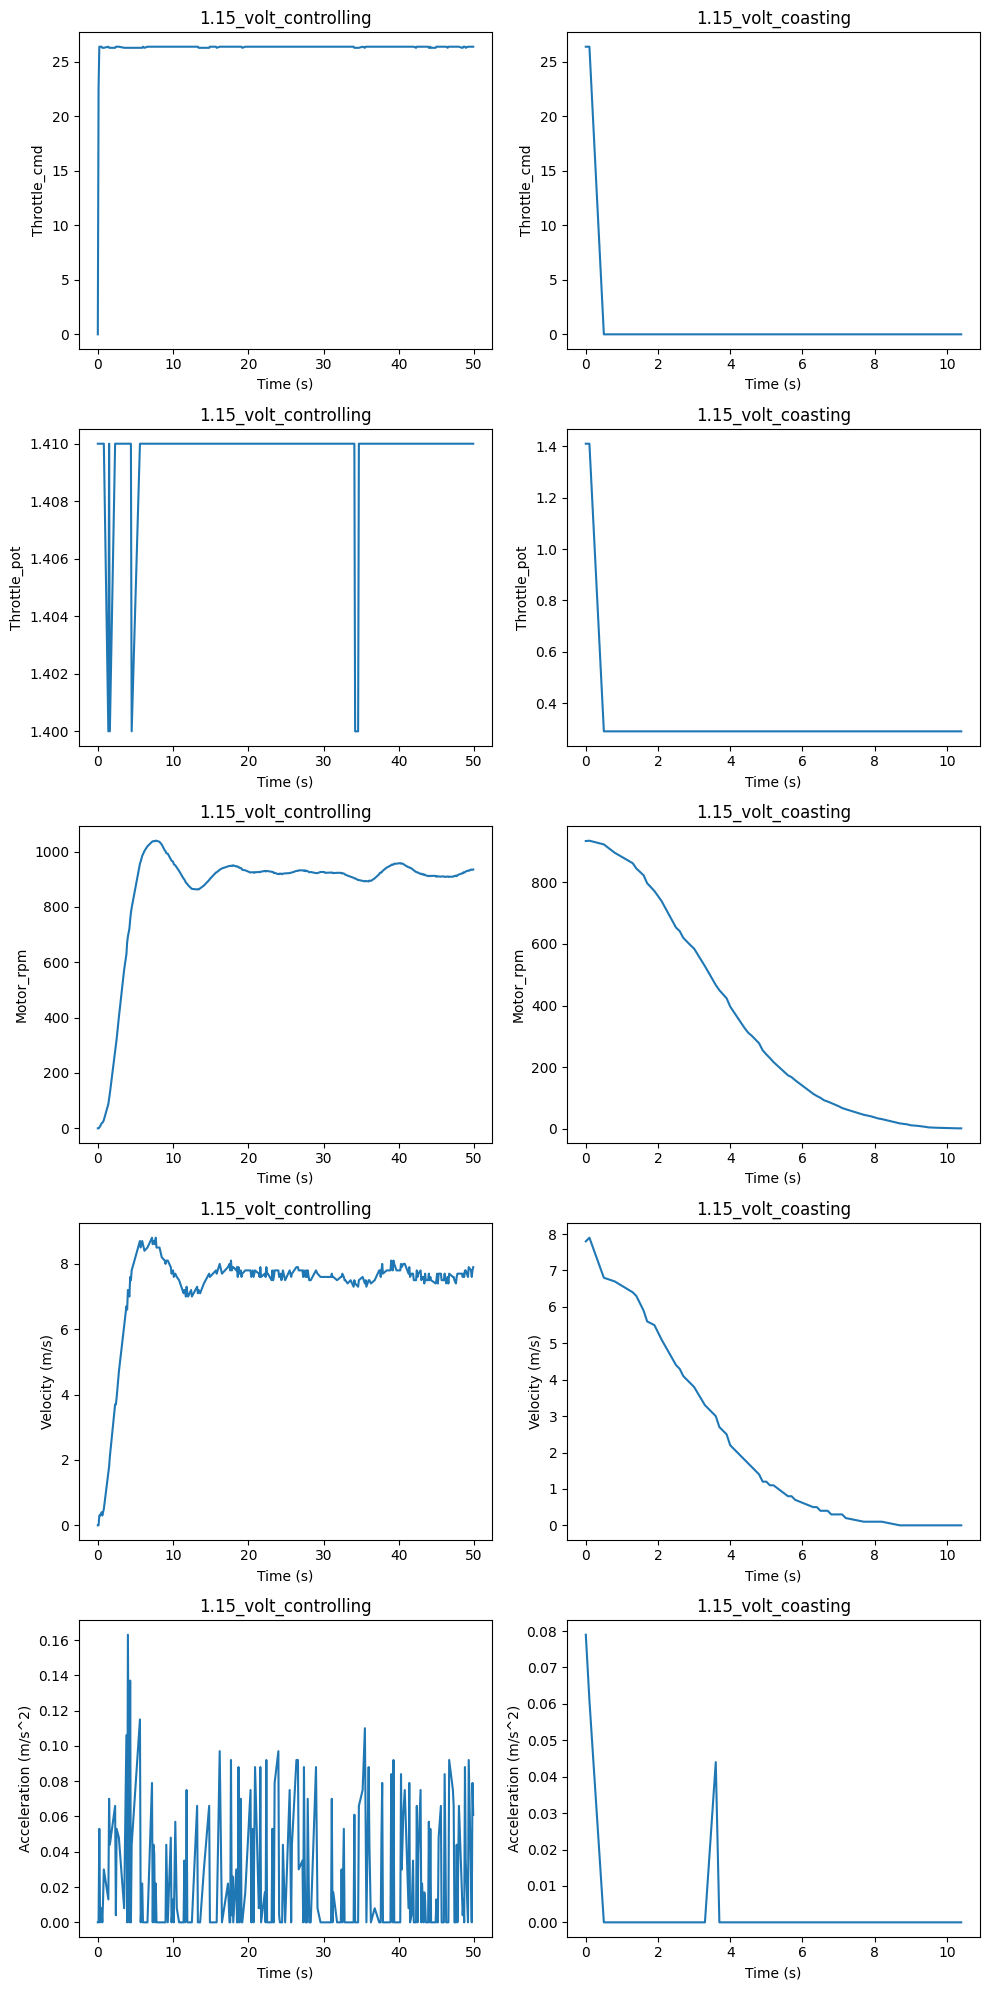

In [46]:
plot(altered_data_list[1], store_brakepoints[1], titles[1])

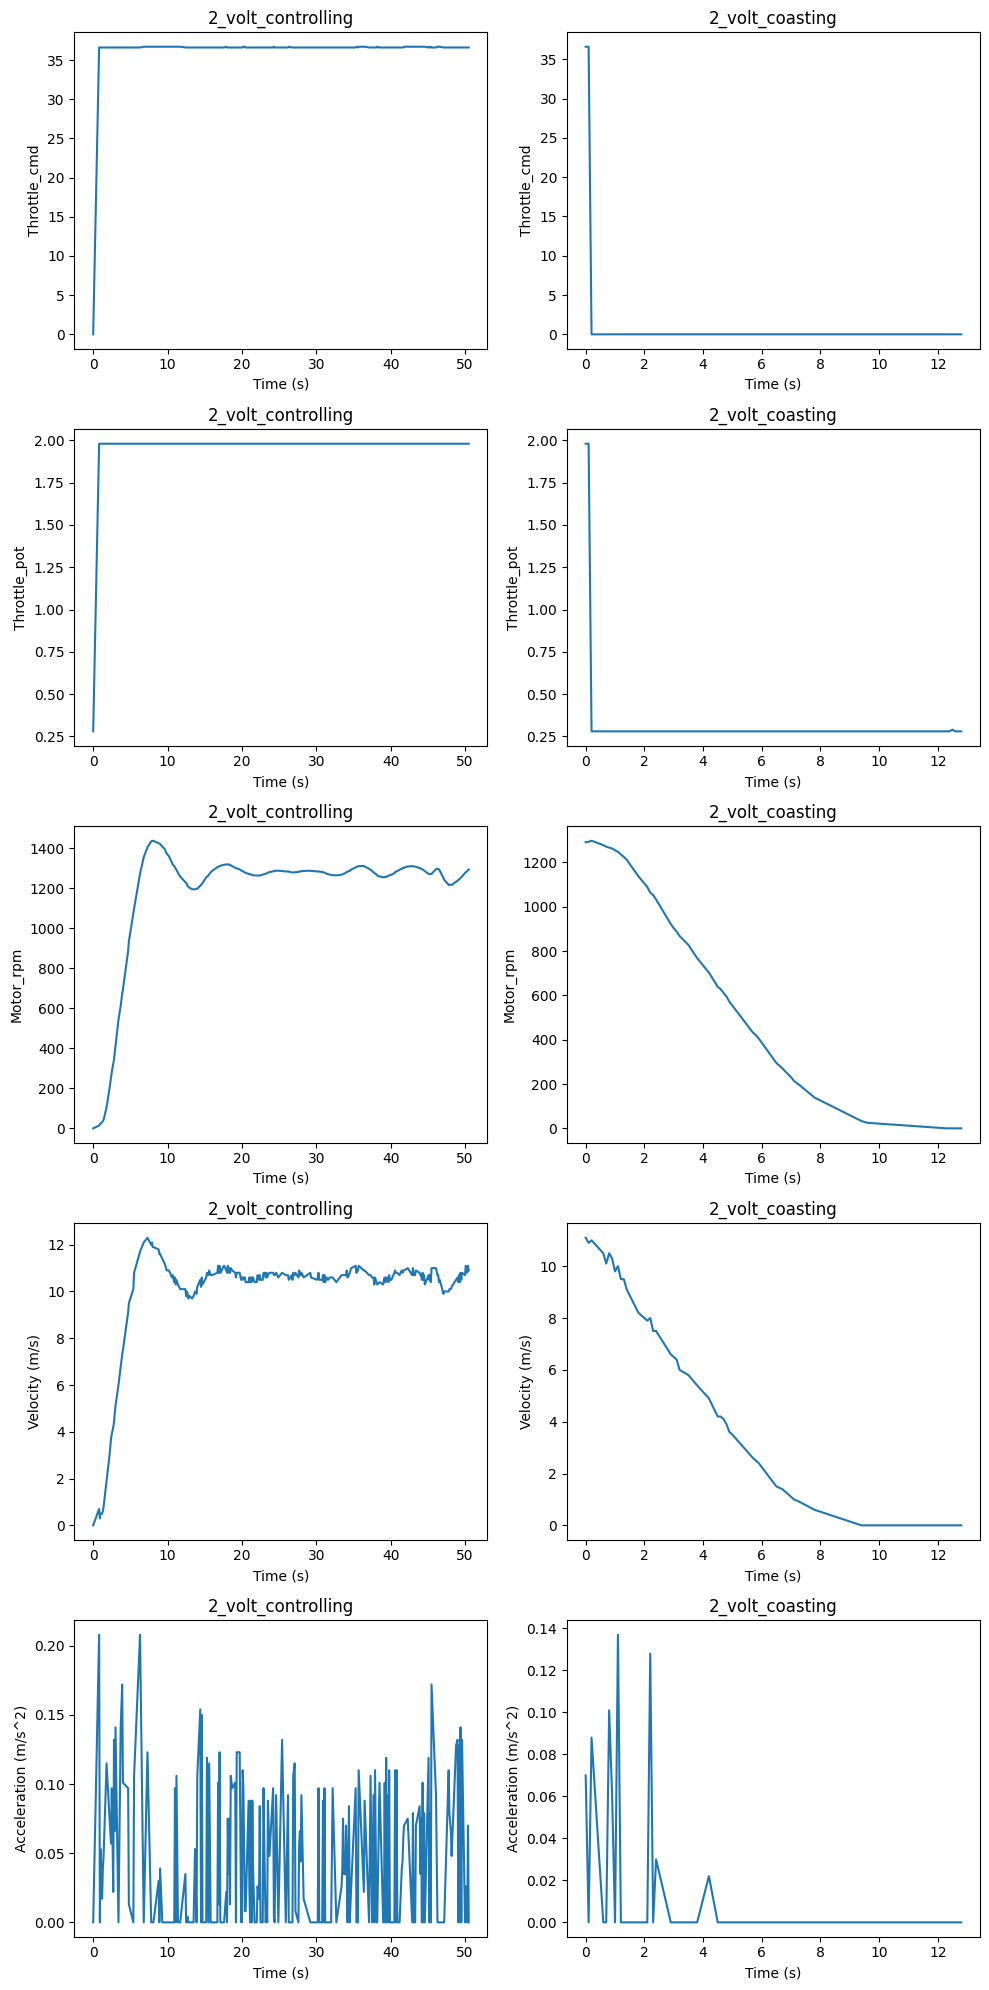

In [47]:
plot(altered_data_list[2], store_brakepoints[2], titles[2])

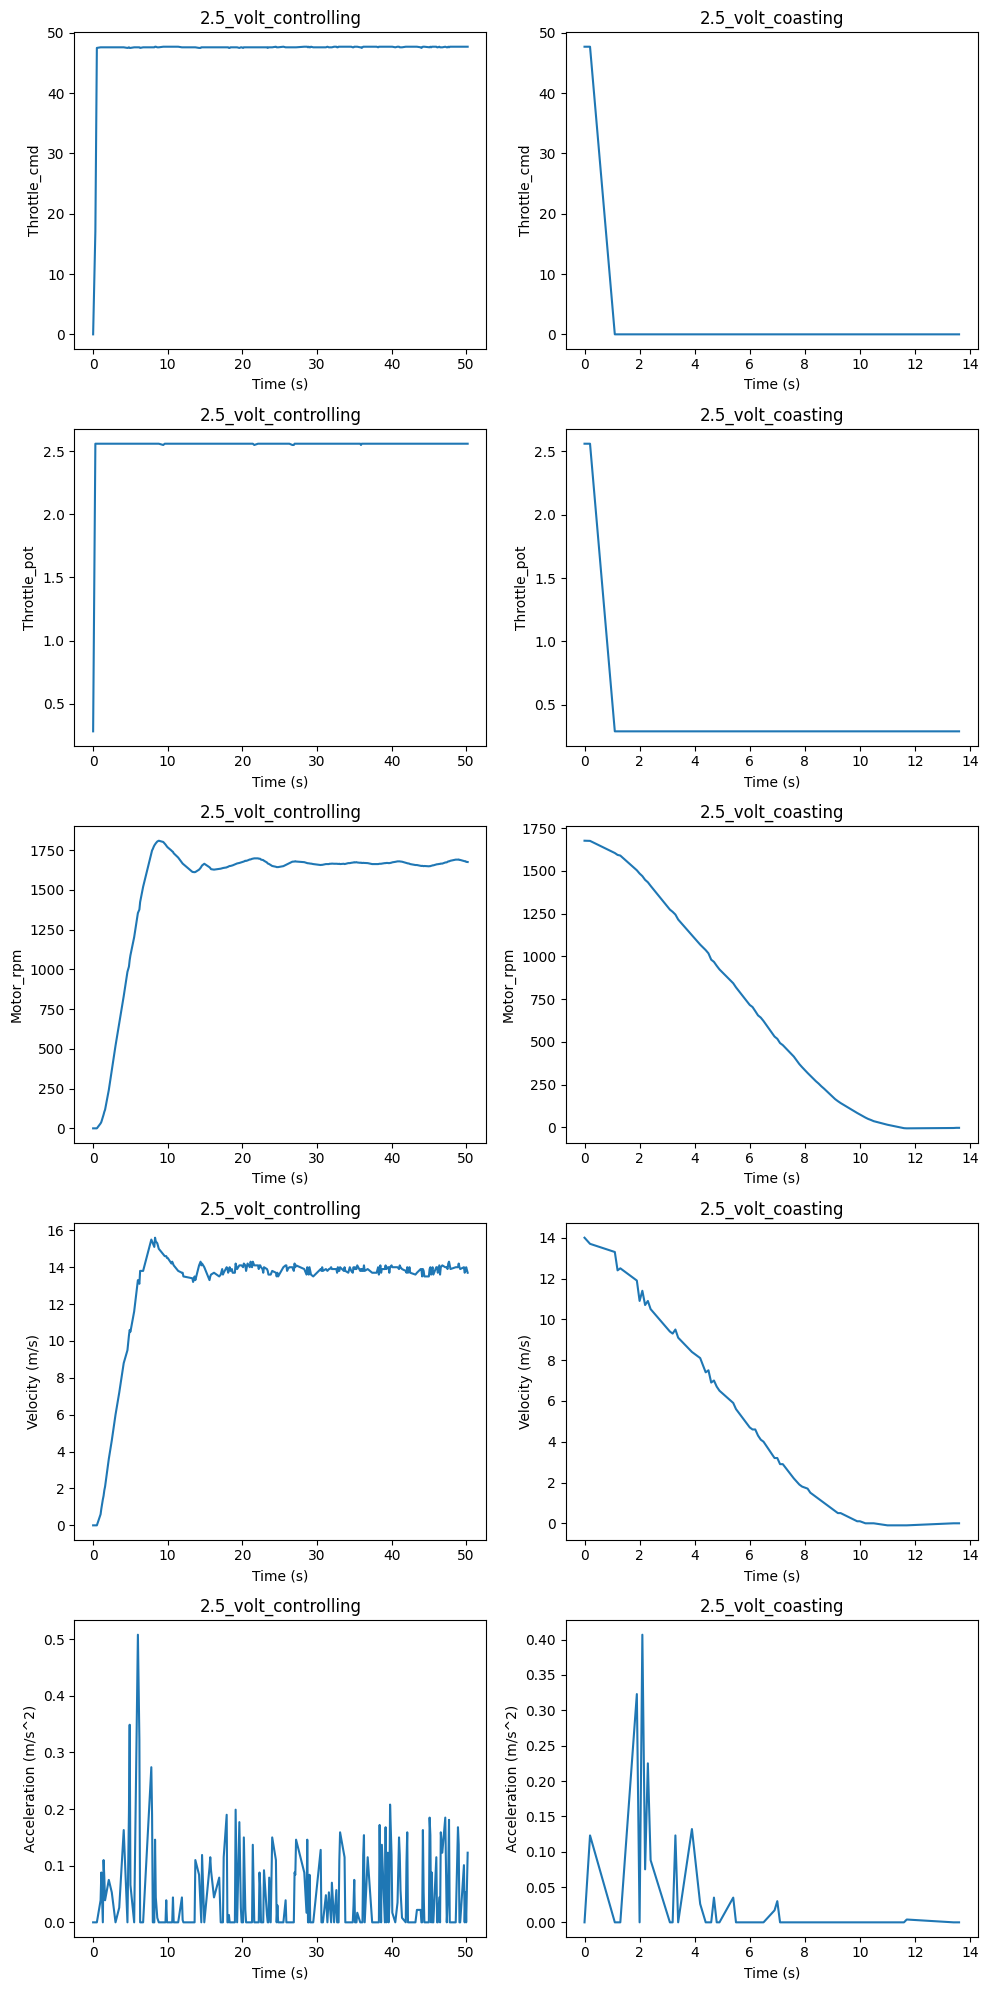

In [48]:
plot(altered_data_list[3], store_brakepoints[3], titles[3])

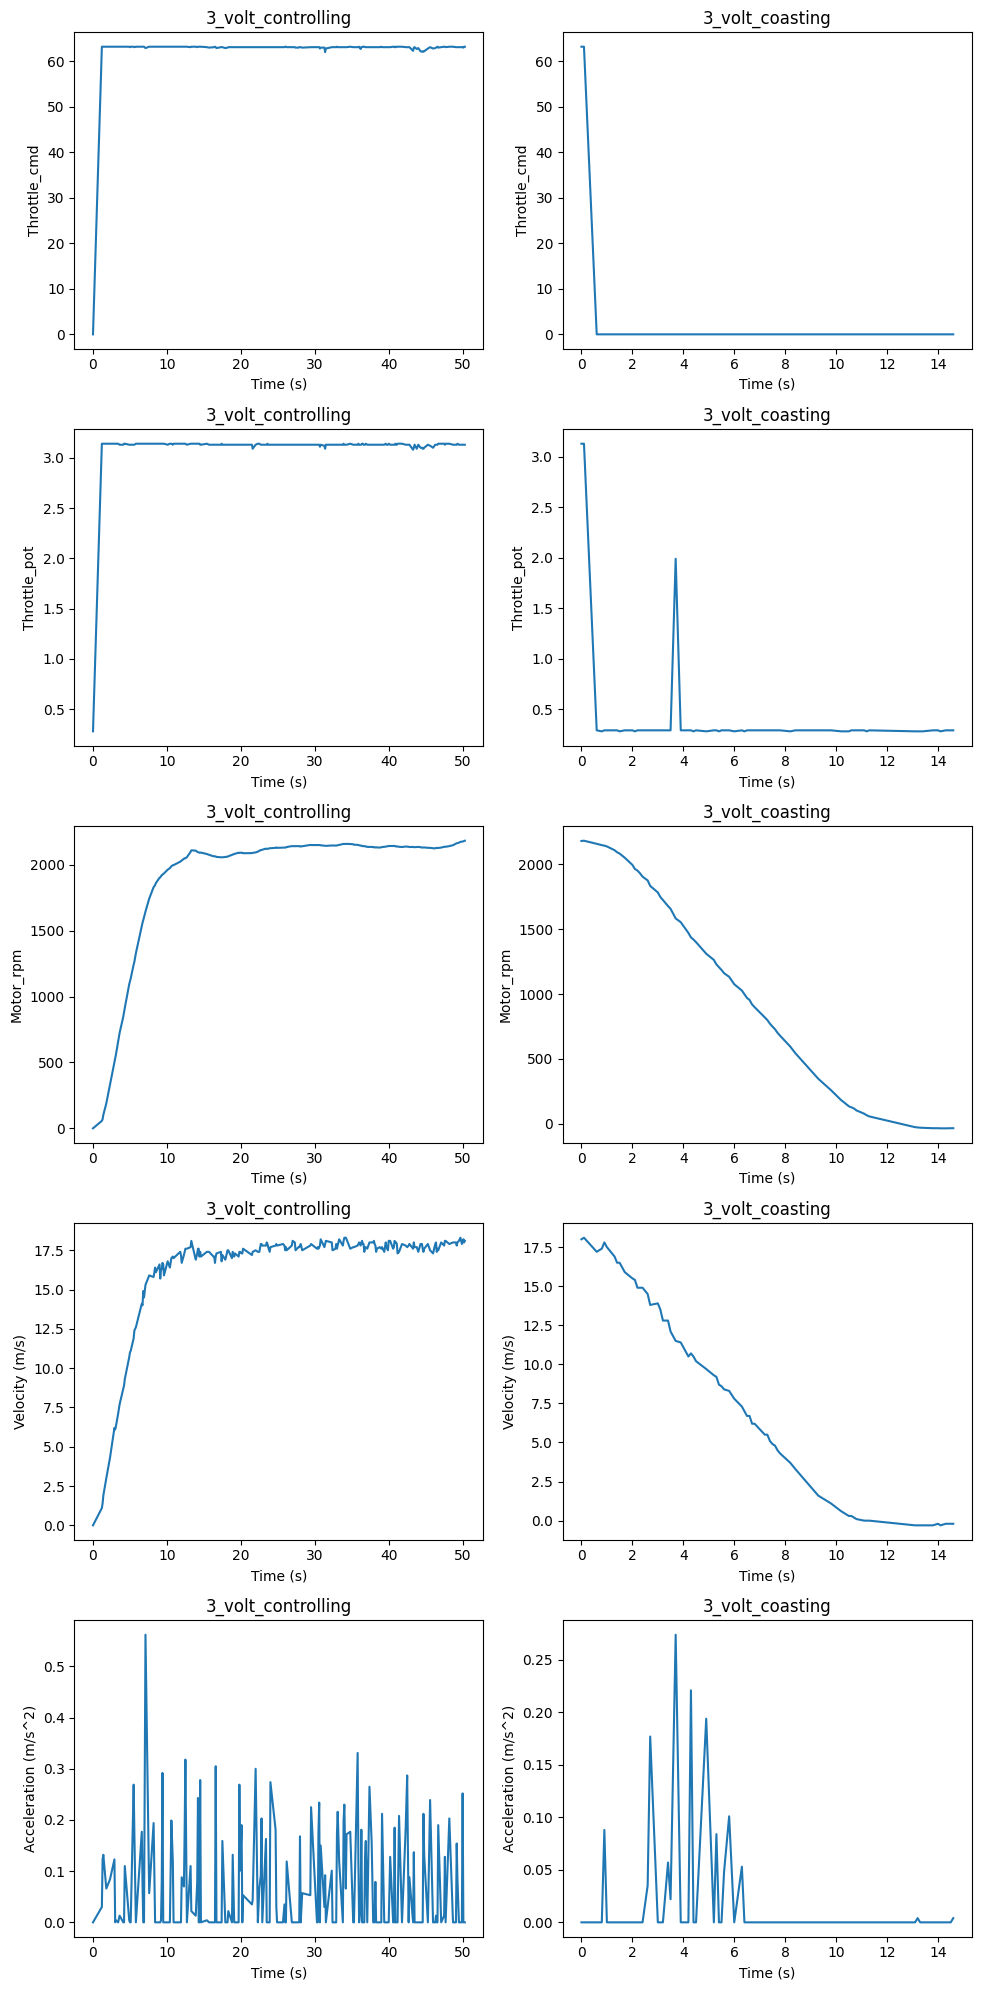

In [49]:
plot(altered_data_list[4], store_brakepoints[4], titles[4])

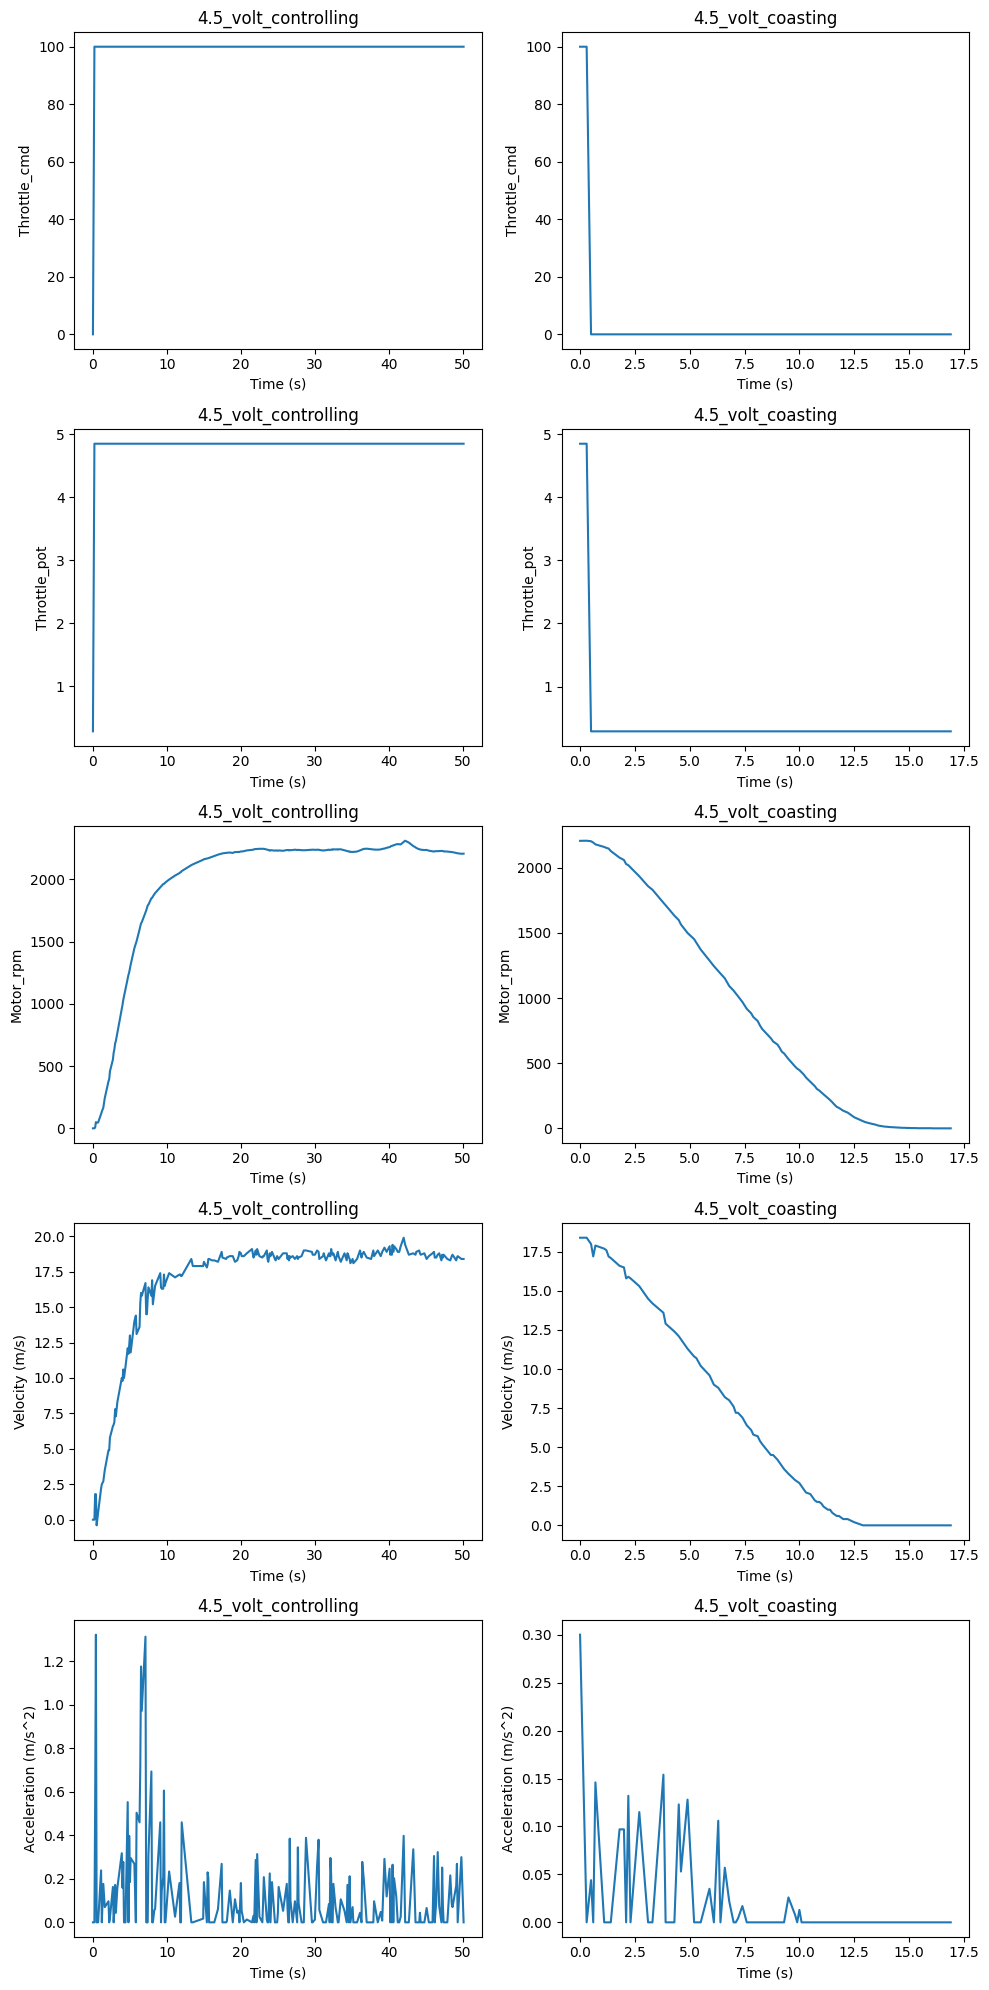

In [50]:
plot(altered_data_list[5], store_brakepoints[5], titles[5])

#### Finding the throttle_pot, throttle_cmd, saturation_rpm, saturation_velocity mapping

In [51]:
requested_throttle_pots = [0.0, 1.0, 1.15, 2.0, 2.5, 3.0, 4.5]
delivered_throttle_pots = [0.28]
delivered_throttle_cmds = [0.0]
mean_saturation_motor_rpms = [0.0]
mean_saturation_velocities = [0.0]
mean_saturation_rpm_to_speed_ratios = [119.67]

for i in range(len(altered_data_list)):
    print(f'The throttle input requested is : {requested_throttle_pots[i + 1]}')
    print(f'The throttle input delivered is : {round(np.mean(altered_data_list[i][2][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)}')
    delivered_throttle_pots.append(round(np.mean(altered_data_list[i][2][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))
    print(f'The throttle command delivered is : {round(np.mean(altered_data_list[i][1][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)}')
    delivered_throttle_cmds.append(round(np.mean(altered_data_list[i][1][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))
    print(f'The mean saturation motor rpm is : {round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)}')
    mean_saturation_motor_rpms.append(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))
    print(f'The mean saturation velocity is : {round(np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)}')
    mean_saturation_velocities.append(round(np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))
    print(f'The mean saturation RPM to SPEED ratio is : {round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]) / np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2)}')
    mean_saturation_rpm_to_speed_ratios.append(round(np.mean(altered_data_list[i][3][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]) / np.mean(altered_data_list[i][4][store_brakepoints[i][1] - 40 : store_brakepoints[i][1]]), 2))
    print()

The throttle input requested is : 1.0
The throttle input delivered is : 0.83
The throttle command delivered is : 15.9
The mean saturation motor rpm is : 558.72
The mean saturation velocity is : 4.62
The mean saturation RPM to SPEED ratio is : 121.0

The throttle input requested is : 1.15
The throttle input delivered is : 1.41
The throttle command delivered is : 26.38
The mean saturation motor rpm is : 916.0
The mean saturation velocity is : 7.6
The mean saturation RPM to SPEED ratio is : 120.45

The throttle input requested is : 2.0
The throttle input delivered is : 1.98
The throttle command delivered is : 36.64
The mean saturation motor rpm is : 1271.47
The mean saturation velocity is : 10.59
The mean saturation RPM to SPEED ratio is : 120.06

The throttle input requested is : 2.5
The throttle input delivered is : 2.56
The throttle command delivered is : 47.66
The mean saturation motor rpm is : 1667.02
The mean saturation velocity is : 13.89
The mean saturation RPM to SPEED ratio is :

Text(0.5, 1.0, 'Delivered Throttle pots vs Requested Throttle pots')

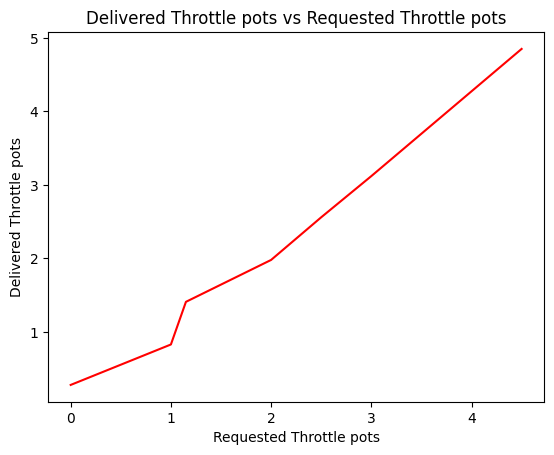

In [52]:
plt.plot(requested_throttle_pots, delivered_throttle_pots, color = 'red')
plt.xlabel('Requested Throttle pots')
plt.ylabel('Delivered Throttle pots')
plt.title('Delivered Throttle pots vs Requested Throttle pots')

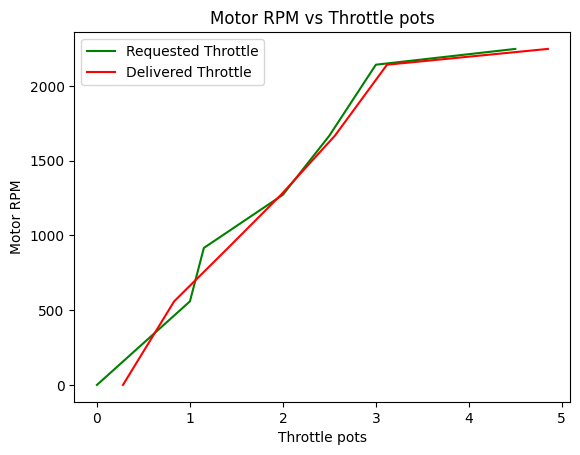

In [53]:
plt.plot(requested_throttle_pots, mean_saturation_motor_rpms, label = 'Requested Throttle', color = 'green')
plt.plot(delivered_throttle_pots, mean_saturation_motor_rpms, label = 'Delivered Throttle', color = 'red')
plt.xlabel('Throttle pots')
plt.ylabel('Motor RPM')
plt.title('Motor RPM vs Throttle pots')
plt.legend()

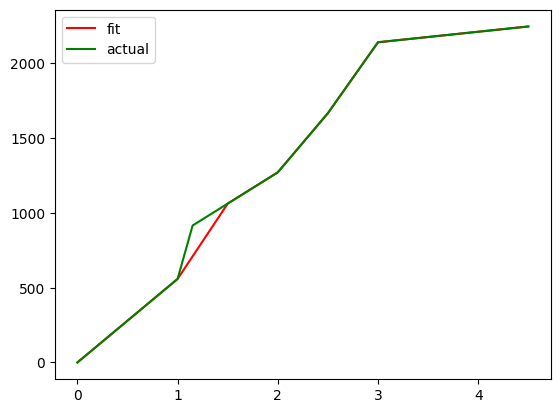

In [54]:
Rbf_interp = Rbf(requested_throttle_pots, mean_saturation_motor_rpms, function = 'linear') 
new_throttle_pots = np.linspace(requested_throttle_pots[0], requested_throttle_pots[-1], 10)
new_motor_rpms = Rbf_interp(new_throttle_pots)
plt.plot(new_throttle_pots, new_motor_rpms, label = 'fit', color = 'red')
plt.plot(requested_throttle_pots, mean_saturation_motor_rpms, label = 'actual', color = 'green')
plt.legend()
plt.show()

#### Storing the Rbf coefficients in a pickle file

In [55]:
folder_path = r'D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis'
file_path = os.path.join(folder_path, 'rbf_model_throttle_pot_to_motor_rpm.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(Rbf_interp, f)

print(f"RBF Interpolator saved at : {file_path}")

RBF Interpolator saved at : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis\rbf_model_throttle_pot_to_motor_rpm.pkl


#### Retrieving the Rbf coefficients from a pickle file

In [56]:
with open(file_path, 'rb') as f:
    Rbf_interp = pickle.load(f)

print(f"RBF Interpolator loaded from : {file_path}")

RBF Interpolator loaded from : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis\rbf_model_throttle_pot_to_motor_rpm.pkl


#### Storing the brake points

In [57]:
folder_path = r'D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis'
file_path = os.path.join(folder_path, 'data_brake_points.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(store_brakepoints, f)

print(f"The brake points for data has been saved at : {file_path}")

The brake points for data has been saved at : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis\data_brake_points.pkl


In [58]:
with open(file_path, 'rb') as f:
    store_brakepoints = pickle.load(f)

print(f"The brake points for data has been loaded from : {file_path}")
print(f"The brake points are : {store_brakepoints}")

The brake points for data has been loaded from : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis\data_brake_points.pkl
The brake points are : [(50, 283, 326), (13, 246, 299), (42, 282, 329), (46, 279, 338), (74, 286, 357), (77, 284, 380)]


#### Storing other data

In [59]:
folder_path = r'D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis'
requested_throttle_pots_file_path = os.path.join(folder_path, 'requested_throtte_pots.pkl')
delivered_throttle_pots_file_path = os.path.join(folder_path, 'delivered_throttle_pots.pkl')
delivered_throttle_cmds_file_path = os.path.join(folder_path, 'delivered_throttle_cmds.pkl')
mean_saturation_motor_rpms_file_path = os.path.join(folder_path, 'mean_saturated_motor_rpms.pkl')
with open(requested_throttle_pots_file_path, 'wb') as f:
    pickle.dump(requested_throttle_pots, f)
    
with open(delivered_throttle_pots_file_path, 'wb') as f:
    pickle.dump(delivered_throttle_pots, f)

with open(delivered_throttle_cmds_file_path, 'wb') as f:
    pickle.dump(delivered_throttle_cmds, f)
    
with open(mean_saturation_motor_rpms_file_path, 'wb') as f:
    pickle.dump(mean_saturation_motor_rpms, f)

print(f"The required data has been saved at : {folder_path}")

The required data has been saved at : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis


In [60]:
folder_path = r'D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis'
altered_data_list_file_path = os.path.join(folder_path, 'data.pkl')
with open(altered_data_list_file_path, 'wb') as f:
    pickle.dump(altered_data_list, f)

print(f'The vehicle data has been stored at : {folder_path}')

The vehicle data has been stored at : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis


#### Getting the relation between throttle command and motor rpm

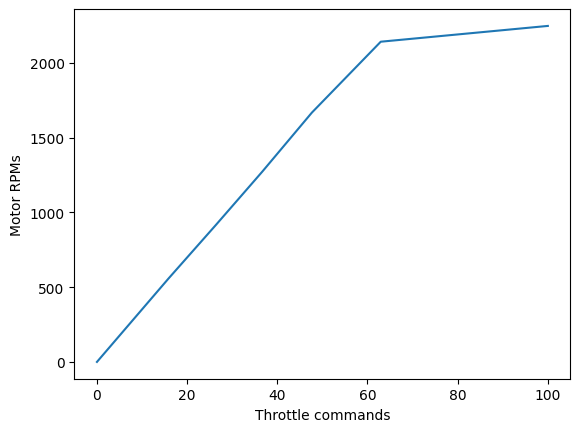

In [61]:
plt.plot(delivered_throttle_cmds, mean_saturation_motor_rpms)
plt.xlabel('Throttle commands')
plt.ylabel('Motor RPMs')
plt.show()

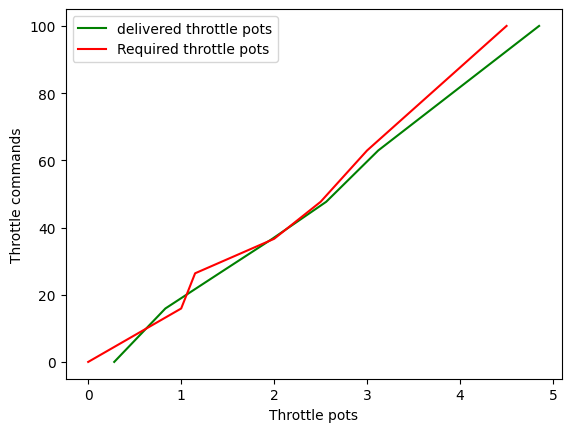

In [62]:
plt.plot(delivered_throttle_pots, delivered_throttle_cmds, label = 'delivered throttle pots', color = 'green')
plt.plot(requested_throttle_pots, delivered_throttle_cmds, label = 'Required throttle pots', color = 'red')
plt.xlabel('Throttle pots')
plt.ylabel('Throttle commands')
plt.legend()
plt.show()

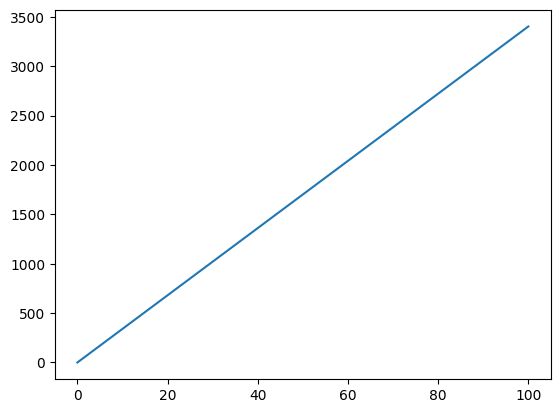

In [63]:
slope = (mean_saturation_motor_rpms[-2] - mean_saturation_motor_rpms[0]) / (delivered_throttle_cmds[-2] - delivered_throttle_cmds[0])
predicted_motor_rpms = [slope * delivered_throttle_cmds[i] for i in range(len(delivered_throttle_cmds))]
plt.plot(delivered_throttle_cmds, predicted_motor_rpms)
plt.show()

In [64]:
print(f'Throttle command for current max RPM of the vehicle is : {mean_saturation_motor_rpms[-1] / slope}')

Throttle command for current max RPM of the vehicle is : 66.04335086162612


In [65]:
folder_path = r'D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis'
slope_rpm_tcmd_file_path = os.path.join(folder_path, 'slope_rpm_tcmd.pkl')
with open(slope_rpm_tcmd_file_path, 'wb') as f:
    pickle.dump([slope], f)

print(f'The slope of rpm vs tcmd has been stored at : {folder_path}')

The slope of rpm vs tcmd has been stored at : D:\lord_of_darkness\IITM\5th_year\DDP_Final\2_Data_Analysis
